# NB07 — Fusión con densidad mamaria sobre la mejor configuración

## Propósito

Probar si añadir la **densidad mamaria** (una covariable clínica conocida) como input adicional a la mejor configuración (`M_A_mlp`, AUC test = 0.683) mejora el rendimiento.

## Justificación clínica

La densidad mamaria es uno de los **factores de riesgo más estudiados** para cáncer de mama:

- BI-RADS clasifica la densidad en 4 categorías: **A** (casi totalmente grasa), **B** (densidad fibroglandular dispersa), **C** (heterogéneamente densa) y **D** (extremadamente densa).
- Mujeres con densidad **D** tienen aproximadamente **4-6 veces más riesgo** de cáncer de mama que mujeres con densidad **A**.
- Además, la densidad alta **enmascara lesiones** en mamografía (el tejido denso es radiopaco y oculta lesiones, también radiopacas), lo que reduce la sensibilidad del cribado.
- En la práctica clínica, la densidad mamaria ya forma parte de la interpretación: muchos países (incluyendo EEUU desde 2024) obligan a comunicar la densidad al paciente.

Por tanto es una **covariable clínicamente relevante y disponible** (VinDr la incluye en el CSV). La pregunta empírica es: **¿el modelo ya está captando implícitamente la densidad desde los embeddings del backbone, o añadirla explícitamente aporta información complementaria?**

## Estrategia: fusión tardía simple

Tomamos la mejor configuración y le añadimos la densidad como features adicionales:

- **Vector base (M-A)**: 2048 dims (CC + MLO de la mama).
- **Densidad por mama** (`density_L` o `density_R` según corresponda) **one-hot a 4 dims** (A, B, C, D).
- **Vector fusionado**: 2048 + 4 = **2052 dims**.

Es una **fusión tardía**: en lugar de inyectar la densidad en el backbone (impracticable porque está congelado), la inyectamos en el input de la cabeza. El MLP/GBM aprenden a combinarla con las features de imagen.

## Protocolo

Replicamos exactamente el protocolo del NB05 para hacer la comparación limpia:

- Mismos splits predefinidos de VinDr (training 4.000 / test 1.000).
- Mismo StratifiedGroupKFold(5) con `groups=study_id` y la misma semilla.
- Misma arquitectura de cabeza (MLP con `hidden = max(64, in_dim // 16)`, ahora `2052 // 16 = 128`).
- Mismos hiperparámetros (Adam lr=1e-3, batch=128, patience=15).

Entrenamos **dos cabezas con densidad**:
- `M_A_mlp_dens` — MLP
- `M_A_gbm_dens` — LightGBM

Y los comparamos con sus versiones sin densidad (`M_A_mlp` y `M_A_gbm`) mediante DeLong pareado: como las predicciones son sobre las **mismas mamas**, el test pareado es aplicable y es el correcto.

In [1]:
import os, sys, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy import stats
import lightgbm as lgb

# Raíz del proyecto: por defecto, la carpeta padre de notebooks/.
# Sobrescribible con la variable de entorno TFM_PROJECT_ROOT.
BASE      = os.environ.get('TFM_PROJECT_ROOT',
                           os.path.abspath(os.path.join(os.getcwd(), '..')))
OUTPUTS      = os.path.join(BASE, 'outputs')
FEATURES_DIR = os.path.join(OUTPUTS, 'Features')
PRED_DIR     = os.path.join(OUTPUTS, 'Predicciones')
PLOTS_DIR    = os.path.join(OUTPUTS, 'Plots')
NB_DIR    = os.path.join(BASE, 'src')
for d in (PRED_DIR, PLOTS_DIR): os.makedirs(d, exist_ok=True)

sys.path.insert(0, NB_DIR)
from tfm_models import build_mlp, build_gbm   # noqa: E402  # type: ignore

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 1. Reconstruir el vector M-A (igual que en NB05)

Cargamos features y reproducimos exactamente la concatenación que hizo NB05 para nivel mama: `[L-CC, L-MLO]` para mama izquierda, `[R-CC, R-MLO]` para mama derecha. Apilamos verticalmente y replicamos `study_id` (para los grupos) y `split` (para el hold-out).

In [2]:
X_view = np.load(os.path.join(FEATURES_DIR, 'X_view.npy'))   # (N, 4, 1024)
meta   = pd.read_csv(os.path.join(FEATURES_DIR, 'metadata.csv'))
N = len(meta)

# Orden de vistas en X_view: 0=L-CC, 1=R-CC, 2=L-MLO, 3=R-MLO
X_MA_L = np.concatenate([X_view[:, 0, :], X_view[:, 2, :]], axis=1)   # (N, 2048)  ← mama L
X_MA_R = np.concatenate([X_view[:, 1, :], X_view[:, 3, :]], axis=1)   # (N, 2048)  ← mama R
X_M_A  = np.concatenate([X_MA_L, X_MA_R], axis=0)                     # (2N, 2048)

y_M      = np.concatenate([meta['y_L'].values, meta['y_R'].values]).astype(int)
groups_M = np.concatenate([meta['study_id'].values, meta['study_id'].values])
split_M  = np.concatenate([meta['split'].values, meta['split'].values])

print(f'X_M_A (sin densidad): {X_M_A.shape}')
print(f'y_M: {y_M.shape}   pos: {y_M.sum()} ({100*y_M.mean():.2f}%)')
print(f'Splits: training={int((split_M=="training").sum())}  test={int((split_M=="test").sum())}')

X_M_A (sin densidad): (9998, 2048)
y_M: (9998,)   pos: 494 (4.94%)
Splits: training=7998  test=2000


## 2. Construir las features de densidad por mama

`metadata.csv` trae `density_L` y `density_R` por estudio. Para alinear con `X_M_A` apilamos primero todas las densidades L y luego todas las densidades R (mismo orden que la concatenación de features).

Aplicamos **one-hot encoding** sobre las 4 categorías A, B, C, D. Si por error apareciera otra categoría, el one-hot la dejaría como vector cero (raro en VinDr, pero seguro contra valores inesperados).

**Distribución típica en VinDr**: A es muy minoritaria (~0,5%), C es mayoritaria (~76%), D moderada (~13%). Esta distribución desequilibrada del input no es problema para el clasificador, pero sí limita lo que puede aprender sobre la categoría A (pocos ejemplos).

In [3]:
DENSITY_CATEGORIES = ['A', 'B', 'C', 'D']

def density_onehot(series):
    """
    Convierte una serie de strings ('A','B','C','D') en matriz one-hot (n, 4).
    Valores no reconocidos quedan como vector cero (no asumimos categoría por defecto).
    """
    n = len(series)
    M = np.zeros((n, len(DENSITY_CATEGORIES)), dtype=np.float32)
    for j, cat in enumerate(DENSITY_CATEGORIES):
        M[:, j] = (series == cat).astype(np.float32)
    return M

# Apilar en el mismo orden que X_M_A: primero todas las L, luego todas las R
density_series = np.concatenate([meta['density_L'].values, meta['density_R'].values])
D_onehot = density_onehot(density_series)

print(f'D_onehot: {D_onehot.shape}')
print(f'Distribución de densidad por mama (sobre las {len(density_series)} mamas):')
for cat in DENSITY_CATEGORIES:
    n_cat = (density_series == cat).sum()
    print(f'  {cat}: {n_cat:5d}  ({100*n_cat/len(density_series):5.2f}%)')
n_otros = len(density_series) - sum((density_series == c).sum() for c in DENSITY_CATEGORIES)
if n_otros: print(f'  otros/NaN: {n_otros}')

# Concatenar features de imagen + densidad
X_M_A_dens = np.concatenate([X_M_A, D_onehot], axis=1).astype(np.float32)
print(f'\nX_M_A_dens (con densidad): {X_M_A_dens.shape}   ← 2048 (imagen) + 4 (densidad) = 2052 dims')

D_onehot: (9998, 4)
Distribución de densidad por mama (sobre las 9998 mamas):
  A:    50  ( 0.50%)
  B:   954  ( 9.54%)
  C:  7644  (76.46%)
  D:  1350  (13.50%)

X_M_A_dens (con densidad): (9998, 2052)   ← 2048 (imagen) + 4 (densidad) = 2052 dims


### 2.1. Sanity check de la densidad como predictor por sí sola

Antes de fusionar, miramos si la densidad **por sí sola** discrimina algo. Esto pone una cota inferior a lo que la densidad podría aportar y nos prepara para interpretar el resultado de la fusión:

- Si densidad sola tiene AUC ≈ 0,50 → no discrimina → fusionarla casi no aportará.
- Si densidad sola tiene AUC > 0,55 → discrimina algo → la fusión puede aportar si la señal es complementaria a la imagen.
- **Importante**: incluso si discrimina mucho por sí sola, la fusión puede no aportar si el modelo de imagen **ya está capturando esa información implícitamente** (las features del backbone pueden estar correlacionadas con densidad).

In [4]:
is_train_M = (split_M == 'training')

# Tasa de positivos por categoría de densidad (en training)
print('Tasa de positivos por categoría de densidad (training):')
for cat in DENSITY_CATEGORIES:
    mask = is_train_M & (density_series == cat)
    n = mask.sum()
    if n == 0: continue
    pos = y_M[mask].sum()
    print(f'  {cat}: n={n:5d}  positivos={pos:4d}  ({100*pos/n:5.2f}%)')

# AUC "trivial" usando la posición de la densidad (A=0, B=1, C=2, D=3) como score:
# es lo más parecido a usar la densidad como predictor ordinal sin entrenar nada
cat_to_idx = {c: i for i, c in enumerate(DENSITY_CATEGORIES)}
score_dens_ordinal = np.array([cat_to_idx.get(c, np.nan) for c in density_series], dtype=float)
valid = is_train_M & np.isfinite(score_dens_ordinal)
auc_dens = roc_auc_score(y_M[valid], score_dens_ordinal[valid])
print(f'\nAUC de densidad-ordinal (A<B<C<D) como predictor solo, training: {auc_dens:.4f}')

Tasa de positivos por categoría de densidad (training):
  A: n=   40  positivos=   3  ( 7.50%)
  B: n=  764  positivos=  54  ( 7.07%)
  C: n= 6114  positivos= 311  ( 5.09%)
  D: n= 1080  positivos=  27  ( 2.50%)

AUC de densidad-ordinal (A<B<C<D) como predictor solo, training: 0.4485


## 3. Funciones de entrenamiento (mismas que NB05)

Replicamos `train_fold_mlp` y `train_fold_gbm` del NB05. **Mismas semillas, mismos hiperparámetros**, para que la única diferencia entre el modelo sin densidad y el modelo con densidad sea la inclusión de las 4 features extra.

In [5]:
def train_fold_mlp(X_tr, y_tr, X_val, y_val, X_test=None,
                   max_epochs=120, batch_size=128, lr=1e-3,
                   weight_decay=1e-4, patience=15):
    Xt  = torch.from_numpy(X_tr).float()
    yt  = torch.from_numpy(y_tr).float().unsqueeze(1)
    Xv  = torch.from_numpy(X_val).float().to(DEVICE)
    Xte = torch.from_numpy(X_test).float().to(DEVICE) if X_test is not None else None

    model = build_mlp(X_tr.shape[1]).to(DEVICE)
    n_pos = max(int(y_tr.sum()), 1)
    n_neg = max(int(len(y_tr) - y_tr.sum()), 1)
    pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    dl = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)

    best_auc, best_state, no_improve = -1.0, None, 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            vp = torch.sigmoid(model(Xv)).cpu().numpy().ravel()
        try: val_auc = roc_auc_score(y_val, vp)
        except ValueError: val_auc = float('nan')
        scheduler.step(val_auc)
        if val_auc > best_auc:
            best_auc = val_auc; best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience: break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        val_probs  = torch.sigmoid(model(Xv)).cpu().numpy().ravel()
        test_probs = torch.sigmoid(model(Xte)).cpu().numpy().ravel() if Xte is not None else None
    return val_probs, test_probs, best_auc

def train_fold_gbm(X_tr, y_tr, X_val, y_val, X_test=None):
    n_pos = max(int(y_tr.sum()), 1)
    n_neg = max(int(len(y_tr) - y_tr.sum()), 1)
    clf = build_gbm(scale_pos_weight=n_neg/n_pos, seed=SEED)
    clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric='auc',
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])
    val_probs  = clf.predict_proba(X_val)[:, 1]
    test_probs = clf.predict_proba(X_test)[:, 1] if X_test is not None else None
    val_auc = roc_auc_score(y_val, val_probs)
    print(clf.feature_importances_[2048:])
    return val_probs, test_probs, val_auc

print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


## 4. Función `train_kfold` con StratifiedGroupKFold

Misma lógica que NB05, especializada para nivel mama (siempre con grupos).

In [6]:
def train_kfold_mama(name, train_fold_fn, X, y, groups, is_train, is_test, n_splits=5):
    print(f'\n=== {name} ===')
    X_tr_pool = X[is_train]; y_tr_pool = y[is_train]; g_tr_pool = groups[is_train]
    X_te_pool = X[is_test];  y_te_pool = y[is_test]

    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof_preds  = np.zeros(len(y_tr_pool), dtype=np.float32)
    test_preds = np.zeros((n_splits, len(y_te_pool)), dtype=np.float32)
    fold_aucs  = []

    for fold, (tr_idx, val_idx) in enumerate(splitter.split(X_tr_pool, y_tr_pool, groups=g_tr_pool), 1):
        t0 = time.time()
        val_p, test_p, val_auc = train_fold_fn(
            X_tr_pool[tr_idx], y_tr_pool[tr_idx],
            X_tr_pool[val_idx], y_tr_pool[val_idx],
            X_test=X_te_pool,
        )
        oof_preds[val_idx] = val_p
        test_preds[fold-1] = test_p
        fold_aucs.append(val_auc)
        print(f'  fold {fold}: val_AUC={val_auc:.4f}  ({time.time()-t0:.1f}s)')

    oof_auc  = roc_auc_score(y_tr_pool, oof_preds)
    test_ens = test_preds.mean(axis=0)
    test_auc = roc_auc_score(y_te_pool, test_ens)
    print(f'  → fold AUCs: {[f"{a:.4f}" for a in fold_aucs]}')
    print(f'  → mean fold AUC: {np.mean(fold_aucs):.4f}  (std {np.std(fold_aucs):.4f})')
    print(f'  → OOF AUC (training): {oof_auc:.4f}')
    print(f'  → Test AUC (hold-out, ensemble): {test_auc:.4f}')

    np.save(os.path.join(PRED_DIR, f'{name}_oof.npy'),  oof_preds)
    np.save(os.path.join(PRED_DIR, f'{name}_test.npy'), test_ens)
    return {'name': name, 'oof_preds': oof_preds, 'test_preds': test_ens,
            'oof_auc': oof_auc, 'test_auc': test_auc,
            'mean_fold_auc': float(np.mean(fold_aucs)), 'std_fold_auc': float(np.std(fold_aucs))}

print('train_kfold_mama definida.')

train_kfold_mama definida.


## 5. Entrenar las dos configuraciones con densidad

In [7]:
is_test_M = (split_M == 'test')

res_mlp_dens = train_kfold_mama('M_A_mlp_dens', train_fold_mlp,
                                 X_M_A_dens, y_M, groups_M, is_train_M, is_test_M)
res_gbm_dens = train_kfold_mama('M_A_gbm_dens', train_fold_gbm,
                                 X_M_A_dens, y_M, groups_M, is_train_M, is_test_M)


=== M_A_mlp_dens ===
  fold 1: val_AUC=0.6538  (3.2s)
  fold 2: val_AUC=0.6297  (1.8s)
  fold 3: val_AUC=0.6697  (4.3s)
  fold 4: val_AUC=0.6468  (2.8s)
  fold 5: val_AUC=0.6267  (3.2s)
  → fold AUCs: ['0.6538', '0.6297', '0.6697', '0.6468', '0.6267']
  → mean fold AUC: 0.6453  (std 0.0159)
  → OOF AUC (training): 0.5637
  → Test AUC (hold-out, ensemble): 0.7067

=== M_A_gbm_dens ===


c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0 0 0 0]
  fold 1: val_AUC=0.5701  (1.6s)


c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0 0 0 0]
  fold 2: val_AUC=0.5938  (1.7s)


c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0 0 0 0]
  fold 3: val_AUC=0.5968  (1.6s)


c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0 0 0 0]
  fold 4: val_AUC=0.6146  (1.7s)
[0 0 0 0]
  fold 5: val_AUC=0.5697  (1.6s)
  → fold AUCs: ['0.5701', '0.5938', '0.5968', '0.6146', '0.5697']
  → mean fold AUC: 0.5890  (std 0.0171)
  → OOF AUC (training): 0.5874
  → Test AUC (hold-out, ensemble): 0.6032


c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\victo\miniconda3\envs\tfm\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 6. Comparación con/sin densidad — DeLong pareado

Cargamos las predicciones de los modelos sin densidad (guardadas por NB05) y las comparamos contra las nuevas con DeLong. Como predicen sobre las **mismas mamas**, el test pareado es directamente aplicable y captura la correlación entre predicciones.

In [8]:
# Recuperar predicciones sin densidad
preds_sin = {
    'M_A_mlp_oof':  np.load(os.path.join(PRED_DIR, 'M_A_mlp_oof.npy')),
    'M_A_mlp_test': np.load(os.path.join(PRED_DIR, 'M_A_mlp_test.npy')),
    'M_A_gbm_oof':  np.load(os.path.join(PRED_DIR, 'M_A_gbm_oof.npy')),
    'M_A_gbm_test': np.load(os.path.join(PRED_DIR, 'M_A_gbm_test.npy')),
}

# Reconstruir y_train e y_test del nivel mama (mismos arrays que en NB06)
y_M_train = y_M[is_train_M]
y_M_test  = y_M[is_test_M]

# Función DeLong pareado (idéntica a la del NB06)
def compute_midrank(x):
    J = np.argsort(x); Z = x[J]; N = len(x)
    T = np.zeros(N, dtype=np.float64); i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]: j += 1
        T[i:j] = 0.5*(i+j-1) + 1; i = j
    T2 = np.empty(N, dtype=np.float64); T2[J] = T
    return T2

def fast_delong(predictions, labels):
    order = np.argsort(-labels)
    labels = labels[order]; predictions = predictions[:, order]
    m = int(labels.sum()); n = len(labels) - m
    pos = predictions[:, :m]; neg = predictions[:, m:]
    k = predictions.shape[0]
    tx = np.empty([k, m]); ty = np.empty([k, n]); tz = np.empty([k, m+n])
    for r in range(k):
        tx[r] = compute_midrank(pos[r]); ty[r] = compute_midrank(neg[r]); tz[r] = compute_midrank(predictions[r])
    aucs = tz[:, :m].sum(axis=1)/(m*n) - (m+1.0)/(2.0*n)
    v01 = (tz[:, :m] - tx)/n
    v10 = 1.0 - (tz[:, m:] - ty)/m
    sx = np.cov(v01); sy = np.cov(v10)
    if k == 1: sx = np.array([[sx]]); sy = np.array([[sy]])
    return aucs, sx/m + sy/n

def delong_paired(scores_a, scores_b, labels):
    aucs, cov = fast_delong(np.vstack([scores_a, scores_b]).astype(np.float64), labels.astype(np.int32))
    a, b = aucs
    var_diff = cov[0,0] + cov[1,1] - 2*cov[0,1]
    z = (b - a) / np.sqrt(max(var_diff, 1e-12))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return {'auc_a': float(a), 'auc_b': float(b),
            'delta': float(b-a), 'z': float(z), 'p_value': float(p)}

In [9]:
# Comparaciones: con densidad (b) vs sin densidad (a). Delta > 0 = mejora al añadir densidad.
comparaciones = [
    ('M_A_mlp', 'M_A_mlp_dens'),
    ('M_A_gbm', 'M_A_gbm_dens'),
]
preds_con = {
    'M_A_mlp_dens_oof':  res_mlp_dens['oof_preds'],
    'M_A_mlp_dens_test': res_mlp_dens['test_preds'],
    'M_A_gbm_dens_oof':  res_gbm_dens['oof_preds'],
    'M_A_gbm_dens_test': res_gbm_dens['test_preds'],
}

delong_rows = []
for split_name, y_s, suffix in [('OOF training', y_M_train, 'oof'),
                                ('test hold-out', y_M_test,  'test')]:
    print(f'\n--- Nivel mama, {split_name} (n={len(y_s)}) ---')
    print(f'{"sin densidad":<14} vs {"con densidad":<14}  {"AUC_sin":>8} {"AUC_con":>8} '
          f'{"Δ":>9} {"z":>7} {"p-valor":>10} {"sig":>4}')
    for a, b in comparaciones:
        s_a = preds_sin[f'{a}_{suffix}']
        s_b = preds_con[f'{b}_{suffix}']
        r = delong_paired(s_a, s_b, y_s)
        sig = '✓' if r['p_value'] < 0.05 else '—'
        print(f'{a:<14} vs {b:<14}  {r["auc_a"]:>8.4f} {r["auc_b"]:>8.4f} '
              f'{r["delta"]:>+9.4f} {r["z"]:>+7.3f} {r["p_value"]:>10.4f}   {sig}')
        r.update({'level': 'mama', 'split': split_name, 'comparison': f'{a} vs {b}'})
        delong_rows.append(r)

df_delong_dens = pd.DataFrame(delong_rows)
df_delong_dens.to_csv(os.path.join(PLOTS_DIR, 'delong_pareado_densidad.csv'), index=False)
print(f'\nGuardado en {PLOTS_DIR}\\delong_pareado_densidad.csv')


--- Nivel mama, OOF training (n=7998) ---
sin densidad   vs con densidad     AUC_sin  AUC_con         Δ       z    p-valor  sig
M_A_mlp        vs M_A_mlp_dens      0.5568   0.5637   +0.0070  +0.388     0.6983   —
M_A_gbm        vs M_A_gbm_dens      0.5874   0.5874   +0.0000  +0.000     1.0000   —

--- Nivel mama, test hold-out (n=2000) ---
sin densidad   vs con densidad     AUC_sin  AUC_con         Δ       z    p-valor  sig
M_A_mlp        vs M_A_mlp_dens      0.6830   0.7067   +0.0238  +0.906     0.3647   —
M_A_gbm        vs M_A_gbm_dens      0.6032   0.6032   +0.0000  +0.000     1.0000   —

Guardado en C:\Users\victo\Documents\TFM\Proyecto\Outputs\Plots\delong_pareado_densidad.csv


## 7. Tabla resumen y AUC con IC bootstrap

Mismas métricas que en NB06, ahora incluyendo los modelos con densidad para poder hacer tabla comparativa.

In [10]:
def auc_ci_bootstrap(y_true, y_score, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(set(y_true[idx])) < 2: continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    aucs = np.array(aucs)
    return (float(roc_auc_score(y_true, y_score)),
            float(np.percentile(aucs, 2.5)),
            float(np.percentile(aucs, 97.5)))

def ece(y_true, y_score, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (y_score >= bins[i]) & (y_score < bins[i+1])
        if m.sum() == 0: continue
        e += (m.sum() / len(y_true)) * abs(y_true[m].mean() - y_score[m].mean())
    return float(e)

rows = []
for name, suffix_preds in [
    ('M_A_mlp',      preds_sin),
    ('M_A_gbm',      preds_sin),
    ('M_A_mlp_dens', preds_con),
    ('M_A_gbm_dens', preds_con),
]:
    for split_name, y_s, suffix in [('OOF training', y_M_train, 'oof'),
                                    ('test hold-out', y_M_test,  'test')]:
        p = suffix_preds[f'{name}_{suffix}']
        auc, lo, hi = auc_ci_bootstrap(y_s, p)
        rows.append({
            'config': name, 'split': split_name,
            'n': len(y_s), 'pos': int(y_s.sum()),
            'auc': auc, 'ic_lo': lo, 'ic_hi': hi,
            'brier': float(brier_score_loss(y_s, p)),
            'ece':   ece(y_s, p),
        })
df_comp = pd.DataFrame(rows)
print(df_comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
df_comp.to_csv(os.path.join(PLOTS_DIR, 'auc_densidad_vs_sin.csv'), index=False)

      config         split    n  pos    auc  ic_lo  ic_hi  brier    ece
     M_A_mlp  OOF training 7998  395 0.5568 0.5269 0.5836 0.3283 0.4261
     M_A_mlp test hold-out 2000   99 0.6830 0.6255 0.7405 0.2221 0.4218
     M_A_gbm  OOF training 7998  395 0.5874 0.5572 0.6173 0.0472 0.0224
     M_A_gbm test hold-out 2000   99 0.6032 0.5411 0.6658 0.0467 0.0344
M_A_mlp_dens  OOF training 7998  395 0.5637 0.5322 0.5939 0.3385 0.4218
M_A_mlp_dens test hold-out 2000   99 0.7067 0.6518 0.7601 0.2064 0.3998
M_A_gbm_dens  OOF training 7998  395 0.5874 0.5572 0.6173 0.0472 0.0224
M_A_gbm_dens test hold-out 2000   99 0.6032 0.5411 0.6658 0.0467 0.0344


## 8. Curvas ROC: sin densidad vs con densidad

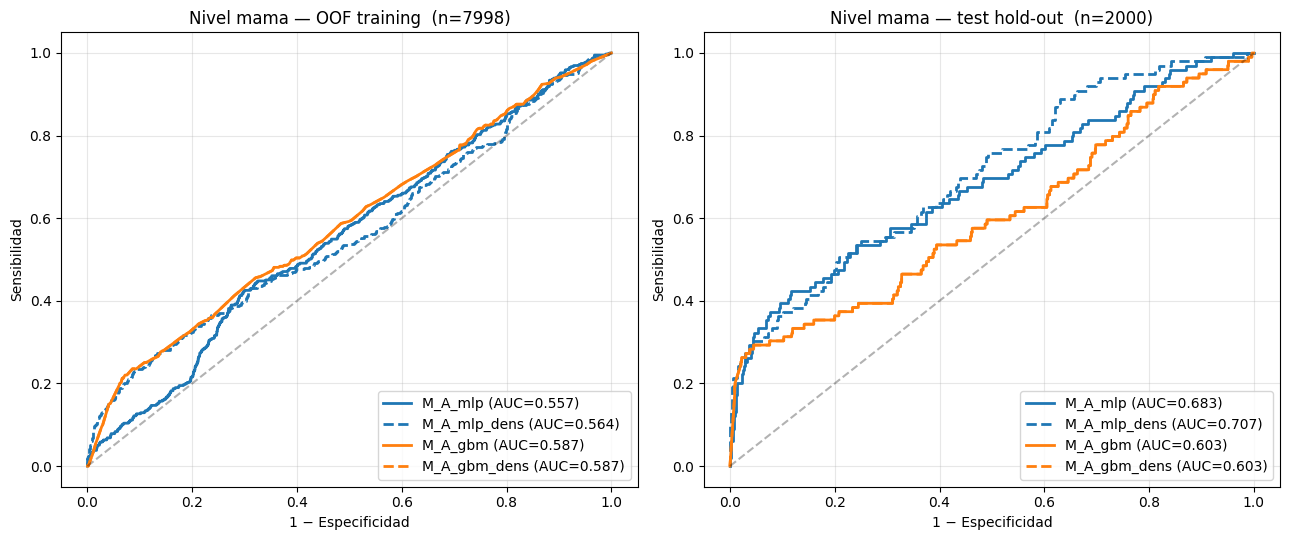

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, split_name, y_s, suffix in [(axes[0], 'OOF training', y_M_train, 'oof'),
                                     (axes[1], 'test hold-out', y_M_test,  'test')]:
    items = [
        ('M_A_mlp',      preds_sin[f'M_A_mlp_{suffix}'],      '-',  'C0'),
        ('M_A_mlp_dens', preds_con[f'M_A_mlp_dens_{suffix}'], '--', 'C0'),
        ('M_A_gbm',      preds_sin[f'M_A_gbm_{suffix}'],      '-',  'C1'),
        ('M_A_gbm_dens', preds_con[f'M_A_gbm_dens_{suffix}'], '--', 'C1'),
    ]
    for name, score, ls, color in items:
        fpr, tpr, _ = roc_curve(y_s, score)
        auc = roc_auc_score(y_s, score)
        ax.plot(fpr, tpr, ls, color=color, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('1 − Especificidad'); ax.set_ylabel('Sensibilidad')
    ax.set_title(f'Nivel mama — {split_name}  (n={len(y_s)})')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_densidad.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Lectura del resultado (para la memoria)

Tres escenarios posibles según los resultados:

**Escenario A: la densidad mejora con p<0.05.**  
Defensa: "Confirmamos que la densidad mamaria es información complementaria a las representaciones de AsymMirai. El backbone, aun habiendo sido entrenado sobre 56.000 mamografías, no captura completamente la densidad: añadirla explícitamente mejora el AUC en X puntos (p=Y)." Cita la literatura sobre densidad como factor de riesgo y como factor de enmascaramiento.

**Escenario B: la densidad no cambia el AUC (Δ pequeño, p alto).**  
Defensa: "El backbone preentrenado de AsymMirai ya captura implícitamente la información sobre densidad mamaria — añadirla como feature adicional no aporta. Esto es consistente con que el ResNet-18 se entrenó con cantidad masiva de mamografías y aprendió representaciones que reflejan estructura de tejido." Es un hallazgo igualmente interesante: hablar de redundancia de información, no de fracaso.

**Escenario C: la densidad empeora el AUC.**  
Defensa: "Añadir densidad como features adicionales aumenta el riesgo de sobreajuste en un dataset pequeño (~395 positivos en training). Los 4 nuevos parámetros desviaron al MLP de su solución óptima." Reportable, aunque honestamente menos brillante. En este caso conviene también probar variantes (concatenar tras BatchNorm, normalizar densidad, etc.) antes de cerrar.

## Fin del desarrollo experimental

Con este notebook cerramos la parte experimental del TFM. Recapitulando los notebooks:

- NB00: plan
- NB01: inspección de AsymMirai
- NB02: validación pipeline 1 estudio
- NB03: extracción masiva 5.000 estudios
- NB04: definición de cabezas MLP y GBM
- NB05: entrenamiento KFold de las 6 configuraciones
- NB06: evaluación (AUC+IC, Brier, ECE, DeLong)
- **NB07: fusión con densidad sobre la mejor configuración** ← este

Próximo paso (fuera de notebook): escribir la memoria con los resultados de NB06 y NB07 como evidencia.